<h4> Imports </h4>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as ipyw
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from skimage import data, transform, exposure
from skimage.util import compare_images

import ants
import scipy
import skimage
import tensorflow as tf
from cids.tensorflow import layers as clayers


<h4> Read Image </h4>

In [ ]:
result1 = np.load(f'/mnt/data/stud-uexja/Documents/MRI_Registration/ANTsReg/ElastixData.npz')
# result1 = np.load(f'/mnt/data/stud-uexja/DATA/vxm_twist_time_128/RESULTS/VXM_Twist--moving+fixed--fixed+moving--MutualInformation--epoch:1001--int_steps:7--bidir:True--reg_field:svf/test_results_inferdata.npz')
result2 = np.load(f'/mnt/data/stud-uexja/Documents/MRI_Registration/ANTsReg/ANTsData.npz')
result3 = np.load(f'/mnt/data/stud-uexja/DATA/vxm_twist_time_128/RESULTS/VXM_Twist--moving+fixed--fixed--NCC--epoch:5001--int_steps:7--bidir:False--reg_field:preintegrated/test_results_inferdata.npz')
result4 = np.load(f'/mnt/data/stud-uexja/DATA/vxm_twist_time_128/RESULTS/VXM_Twist--moving+fixed--fixed--MutualInformation--epoch:5001--int_steps:7--bidir:False--reg_field:preintegrated/test_results_inferdata.npz')

# loss_type = "NCC"
# result1 = np.load(f'/mnt/data/stud-uexja/DATA/vxm_twist_time_128/RESULTS/VXM_Twist--moving+fixed--fixed--{loss_type}--epoch:1001--int_steps:0--bidir:False--reg_field:svf/test_results_inferdata.npz')
# result2 = np.load(f'/mnt/data/stud-uexja/DATA/vxm_twist_time_128/RESULTS/VXM_Twist--moving+fixed--fixed--{loss_type}--epoch:1001--int_steps:7--bidir:False--reg_field:svf/test_results_inferdata.npz')
# result3 = np.load(f'/mnt/data/stud-uexja/DATA/vxm_twist_time_128/RESULTS/VXM_Twist--moving+fixed--fixed+moving--{loss_type}--epoch:1001--int_steps:0--bidir:True--reg_field:svf/test_results_inferdata.npz')


def load_data(data):
    X = data['X'][:,:,:,:,0]
    Y = data['Y'][:,:,:,:,0]
    Y_reg = data['Y_reg'][:,:,:,:,0]
    Y_neg = data['Y_neg'][:,:,:,:,0]
    # Y_fwdfield = data['Y_fwdfield'][:,:,:,:,:]
    # Y_post = data['Y_posfwd'][:,:,:,:,:]
    return X, Y, Y_reg, Y_neg #, Y_fwdfield, Y_post

X, Y, Y_reg_3, Y_neg_3 = load_data(result3)
X, Y, Y_reg_4, Y_neg_4 = load_data(result4)

# Y_reg_1 = result1['Y_reg'][:,:,:,:,0]
# Y_neg_1 = result1['Y_neg'][:,:,:,:,0]
# Y_reg_2 = result2['Y_reg'][:,:,:,:,0]
# Y_neg_2 = result2['Y_neg'][:,:,:,:,0]

Y_reg_1 = result1['Y_reg'][:,:,:,:]
Y_neg_1 = result1['Y_neg'][:,:,:,:]
Y_reg_2 = result2['Y_reg'][:,:,:,:]
Y_neg_2 = result2['Y_neg'][:,:,:,:]

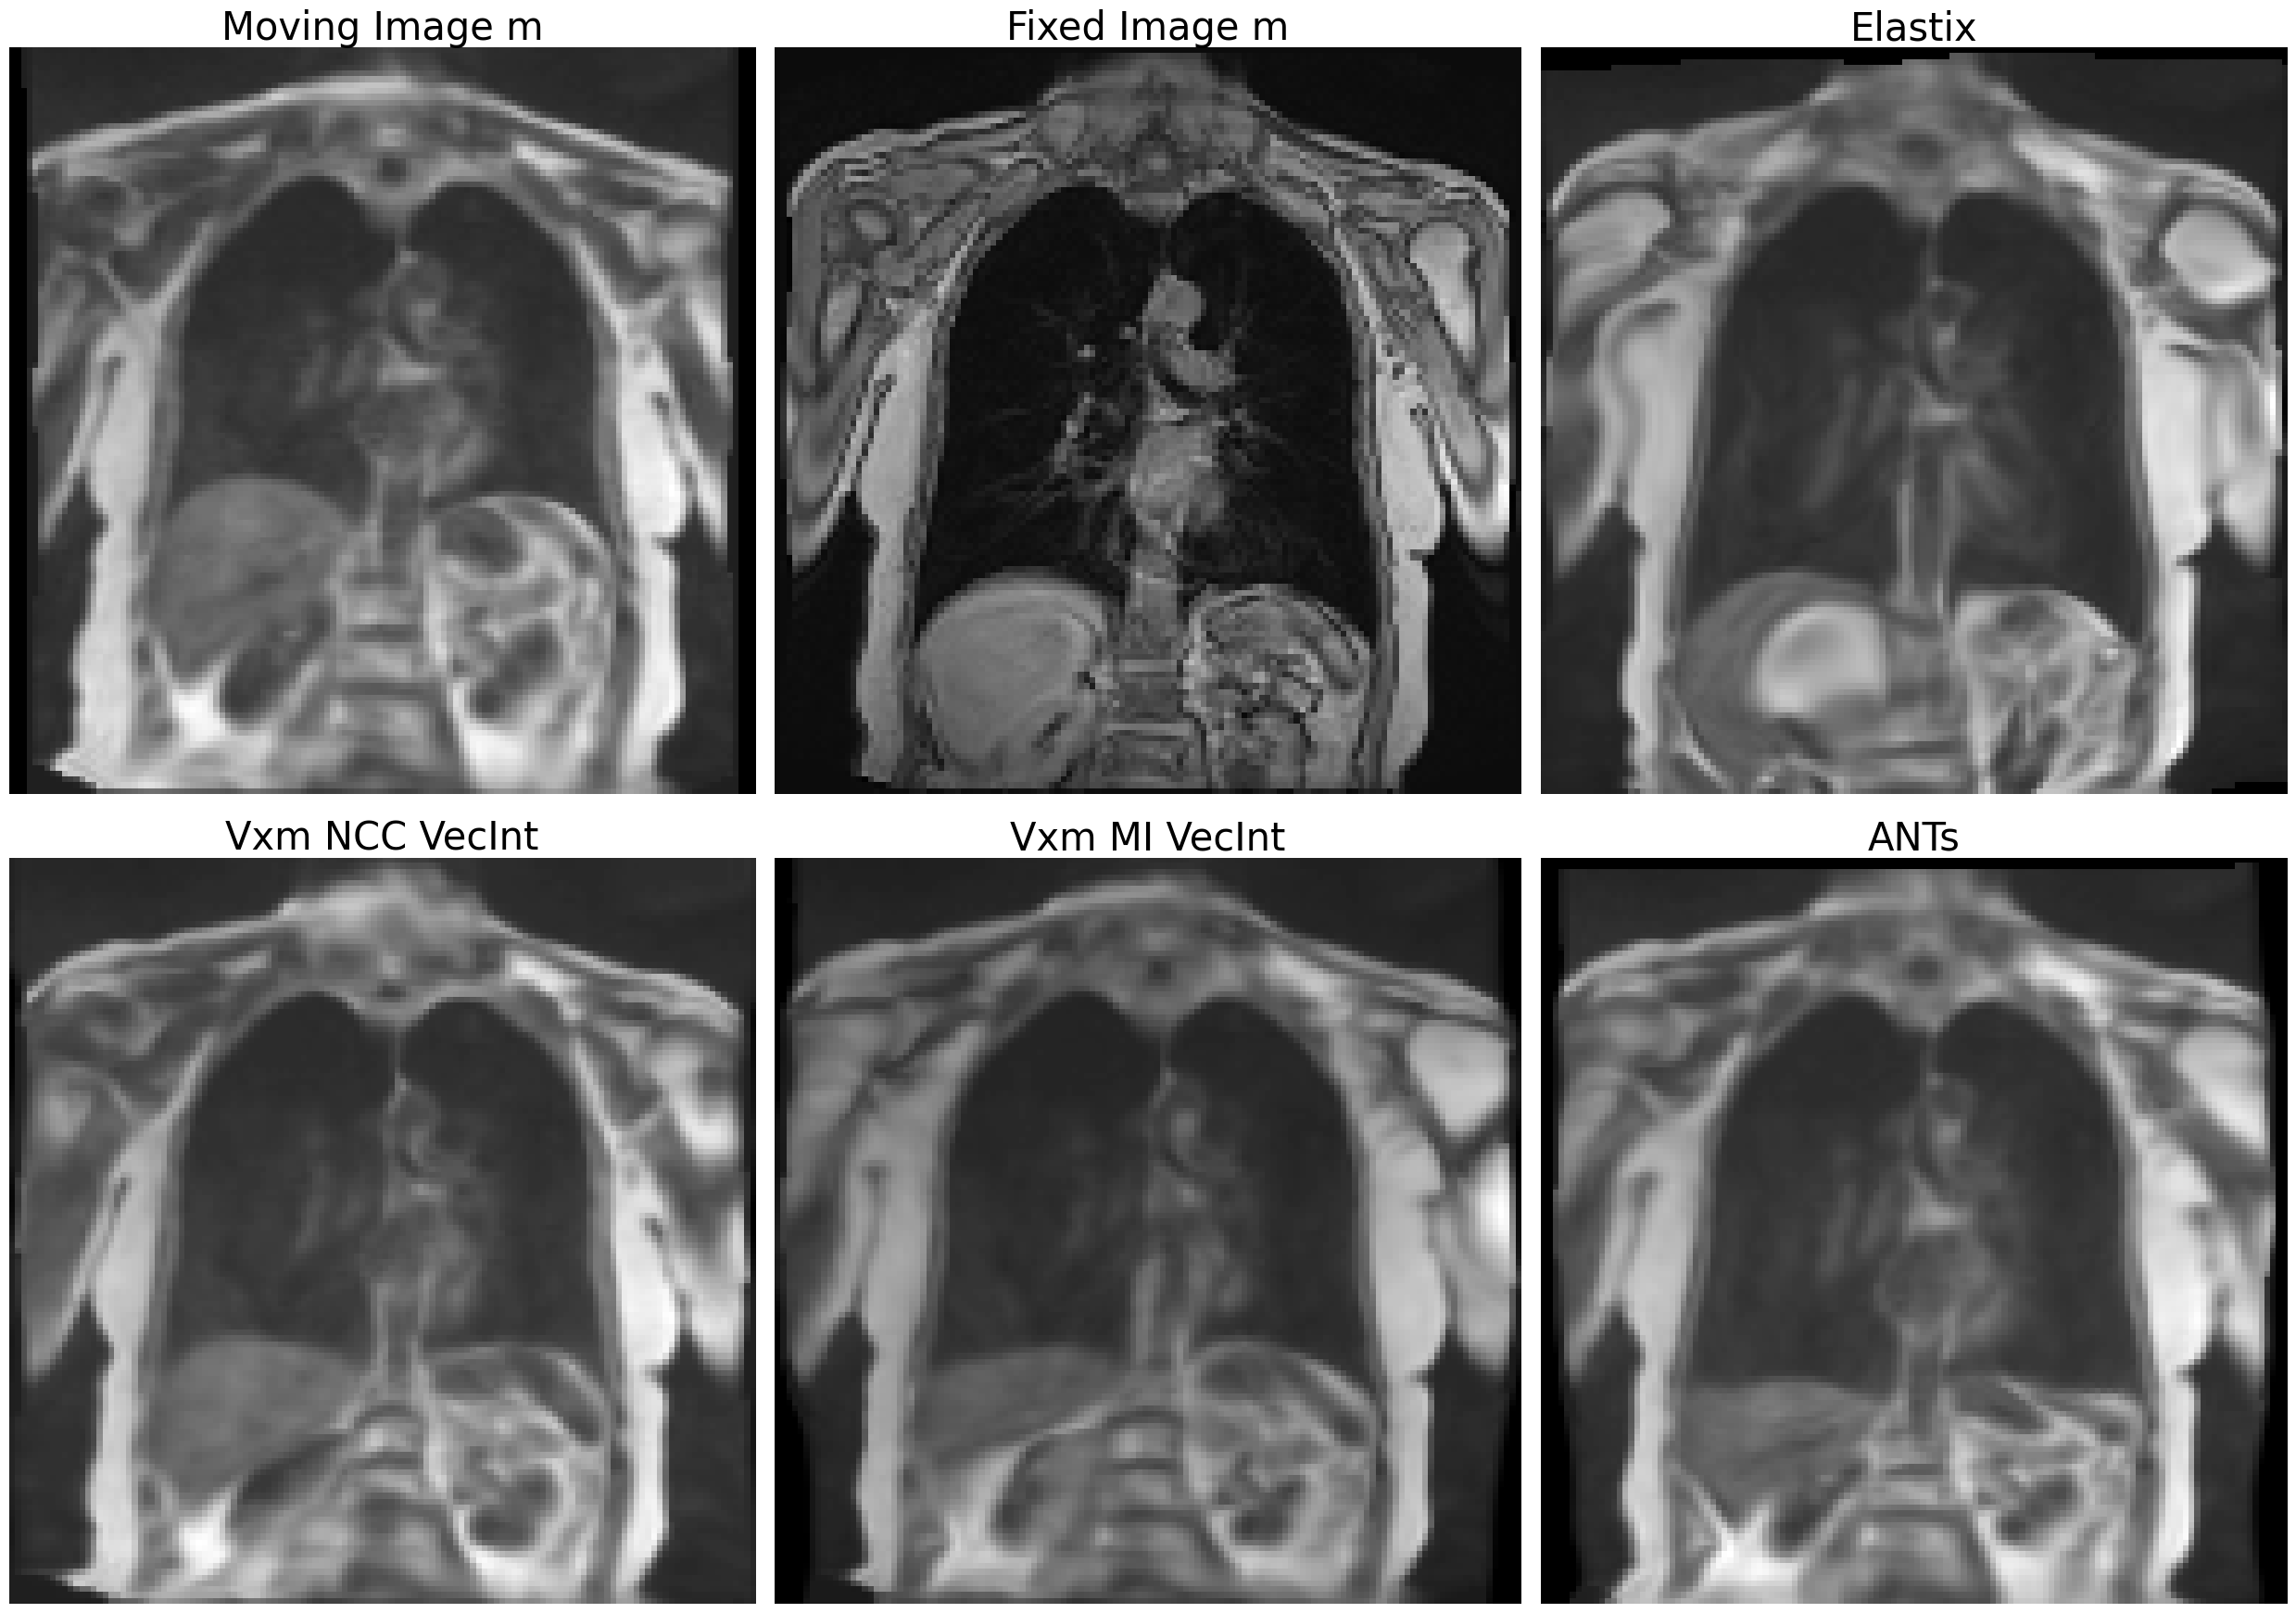

In [181]:
# if loss_type == "MutualInformation":
#     loss_name="MI"
# else:
#     loss_name = loss_type

plt.rcParams.update({
    'font.size': 14,      # Global font size for all elements
    'axes.titlesize': 30, # Title font size
    'axes.labelsize': 14, # Label font size
    'xtick.labelsize': 12, # X-tick labels font size
    'ytick.labelsize': 12, # Y-tick labels font size
    'legend.fontsize': 12, # Legend font size
})

batch = 0
comp1 = compare_images(Y_reg_1[batch, 32,:,:], Y[batch, 32,:,:], method='checkerboard', n_tiles = (8,8))
comp2 = compare_images(Y_reg_2[batch, 32,:,:], Y[batch, 32,:,:], method='checkerboard', n_tiles = (8,8))
comp3 = compare_images(Y_reg_3[batch, 32,:,:], Y[batch, 32,:,:], method='checkerboard', n_tiles = (8,8))
comp4 = compare_images(Y_reg_4[batch, 32,:,:], Y[batch, 32,:,:], method='checkerboard', n_tiles = (8,8))


f,ax = plt.subplots(2,3,figsize=(25,18))



# ax[2].imshow(Y_reg_2[batch, 32,:,:],cmap="gray")
# ax[2].set_title("ANTs")
# ax[2].set_axis_off()

# ax[3].imshow(Y[batch, 32,:,:],cmap="gray")
# ax[3].set_title("Fixed Image f")
# ax[3].set_axis_off()

ax[0,0].imshow(X[batch, 32,:,:],cmap="gray")
ax[0,0].set_title("Moving Image m")
ax[0,0].set_axis_off()

ax[0,1].imshow(Y[batch, 32,:,:],cmap="gray")
ax[0,1].set_title("Fixed Image m")
ax[0,1].set_axis_off()

ax[0,2].imshow(Y_reg_1[batch, 32,:,:],cmap="gray")
ax[0,2].set_title("Elastix")
ax[0,2].set_axis_off()

ax[1,2].imshow(Y_reg_2[batch, 32,:,:],cmap="gray")
ax[1,2].set_title("ANTs")
ax[1,2].set_axis_off()

ax[1,0].imshow(Y_reg_3[batch, 32,:,:],cmap="gray")
ax[1,0].set_title("Vxm NCC VecInt")
ax[1,0].set_axis_off()

ax[1,1].imshow(Y_reg_4[batch, 32,:,:],cmap="gray")
ax[1,1].set_title("Vxm MI VecInt")
ax[1,1].set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
# ax[1].imshow(Y_neg_1[batch,32,:,:],cmap="gray")
# ax[1].set_title(f"Vxm {loss_name} NoMod Inv")
# ax[1].set_axis_off()

# ax[2].imshow(Y_neg_2[batch,32,:,:],cmap="gray")
# ax[2].set_title(f"Vxm {loss_name} VecInt Inv")
# ax[2].set_axis_off()

# ax[3].imshow(Y_neg_3[batch, 32,:,:],cmap="gray")
# ax[3].set_title(f"Vxm {loss_name} Bidir Inv")
# ax[3].set_axis_off()

# ax[0].imshow(X[batch,32,:,:],cmap="gray")
# ax[0].set_title(f"Moving Image m")
# ax[0].set_axis_off()

# ax[2].imshow(Y[batch, 32,:,:],cmap="gray")
# ax[2].set_title(f"Fixed Image f")
# ax[2].set_axis_off()

#############################################################3

# ax[0].imshow(comp1,cmap="gray")
# ax[0].set_title(f"Vxm {loss_name} NoMod")
# ax[0].set_axis_off()

# ax[1].imshow(comp2,cmap="gray")
# ax[1].set_title(f"Vxm {loss_name} VecInt")
# ax[1].set_axis_off()

# ax[2].imshow(comp3,cmap="gray")
# ax[2].set_title(f"Vxm {loss_name} Bidir")
# ax[2].set_axis_off()

#############################################################

In [ ]:
# Load images from npy files
img1 = Y[batch, 32,:,:]
img2 = X[batch, 32,:,:]

# Ensure both images have the same dimensions
assert img1.shape == img2.shape, "Images must have the same shape!"

# Get image dimensions
rows, cols = img1.shape[:2]

# Set the tile size
tile_size = 16

# Create an empty array for the combined image
combined_img = np.zeros_like(img1)

# Loop through the images and fill in the combined image with tiles
for i in range(0, rows, tile_size):
    for j in range(0, cols, tile_size):
        # Get the current tile's dimensions
        tile_row = slice(i, min(i + tile_size, rows))
        tile_col = slice(j, min(j + tile_size, cols))
        
        # Alternate between img1 and img2
        if (i // tile_size) % 2 == (j // tile_size) % 2:
            combined_img[tile_row, tile_col] = img1[tile_row, tile_col]
        else:
            combined_img[tile_row, tile_col] = img2[tile_row, tile_col]

# Display the combined image
plt.imshow(combined_img, cmap="gray")  # Ensure it's in the correct displayable format
plt.axis('off')
plt.show()


<h4> Show Image </h4>

In [ ]:
def ssim_nmi_values(img1,img2, img3, img4,img5, img6, batch):
    tmpimg1 = np.squeeze(img1[batch,:,:,:])
    tmpimg2 = np.squeeze(img2[batch,:,:,:])

    tmpimg3 = np.squeeze(img3[batch,:,:,:])
    tmpimg4 = np.squeeze(img4[batch,:,:,:])
    
    tmpimg5 = np.squeeze(img5[batch,:,:,:])
    tmpimg6 = np.squeeze(img6[batch,:,:,:])

    nmi_original = skimage.metrics.normalized_mutual_information(tmpimg2, tmpimg1)
    nmi_1_reg = skimage.metrics.normalized_mutual_information(tmpimg2, tmpimg5)
    nmi_2_reg = skimage.metrics.normalized_mutual_information(tmpimg2, tmpimg6)
    nmi_1_inv = skimage.metrics.normalized_mutual_information(tmpimg1, tmpimg3)
    nmi_2_inv = skimage.metrics.normalized_mutual_information(tmpimg1, tmpimg4)

    ssim_original = skimage.metrics.structural_similarity(tmpimg2, tmpimg1, data_range = tmpimg1.max() - tmpimg1.min())
    ssim_1_reg = skimage.metrics.structural_similarity(tmpimg2, tmpimg5, data_range = tmpimg5.max() - tmpimg5.min())
    ssim_2_reg = skimage.metrics.structural_similarity(tmpimg2, tmpimg6, data_range = tmpimg6.max() - tmpimg6.min())
    ssim_1_inv = skimage.metrics.structural_similarity(tmpimg1, tmpimg3, data_range = tmpimg3.max() - tmpimg3.min())
    ssim_2_inv = skimage.metrics.structural_similarity(tmpimg1, tmpimg4, data_range = tmpimg4.max() - tmpimg4.min())
    
    print(f"Normalized Mutual Information:\nOriginal      : {nmi_original}\nReg     data 1: {nmi_1_reg}, data 2: {nmi_2_reg}")
    print(f"Inv     data 1: {nmi_1_inv}, data 2: {nmi_2_inv}")
    print()
    print(f"Structural Similarity:\nOriginal      : {ssim_original}\nReg     data 1: {ssim_1_reg}, data 2: {ssim_2_reg}")
    print(f"Inv     data 1: {ssim_1_inv}, data 2: {ssim_2_inv}")


ipyw.interact(
    ssim_nmi_values,
    img1 = ipyw.fixed(X),
    img2 = ipyw.fixed(Y),
    img3 = ipyw.fixed(Y_neg_1),
    img4 = ipyw.fixed(Y_neg_2),
    img5 = ipyw.fixed(Y_reg_1),
    img6 = ipyw.fixed(Y_reg_2),
    batch = ipyw.IntSlider(min=0,max=Y.shape[0]-1,step=1,value=0),
    )

In [ ]:
def plot_imgs_side_by_side(img1,img2, img3, img4,img5, img6, batch,slice_num):
    tmpimg1 = np.squeeze(img1[batch,slice_num,:,:])
    tmpimg2 = np.squeeze(img2[batch,slice_num,:,:])

    tmpimg3 = np.squeeze(img3[batch,slice_num,:,:])
    tmpimg4 = np.squeeze(img4[batch,slice_num,:,:])
    
    tmpimg5 = np.squeeze(img5[batch,slice_num,:,:])
    tmpimg6 = np.squeeze(img6[batch,slice_num,:,:])

    nmi_original = skimage.metrics.normalized_mutual_information(tmpimg2, tmpimg1)
    nmi_1_reg = skimage.metrics.normalized_mutual_information(tmpimg2, tmpimg5)
    nmi_2_reg = skimage.metrics.normalized_mutual_information(tmpimg2, tmpimg6)
    nmi_1_inv = skimage.metrics.normalized_mutual_information(tmpimg1, tmpimg3)
    nmi_2_inv = skimage.metrics.normalized_mutual_information(tmpimg1, tmpimg4)

    ssim_original = skimage.metrics.structural_similarity(tmpimg2, tmpimg1, data_range = tmpimg1.max() - tmpimg1.min())
    ssim_1_reg = skimage.metrics.structural_similarity(tmpimg2, tmpimg5, data_range = tmpimg5.max() - tmpimg5.min())
    ssim_2_reg = skimage.metrics.structural_similarity(tmpimg2, tmpimg6, data_range = tmpimg6.max() - tmpimg6.min())
    ssim_1_inv = skimage.metrics.structural_similarity(tmpimg1, tmpimg3, data_range = tmpimg3.max() - tmpimg3.min())
    ssim_2_inv = skimage.metrics.structural_similarity(tmpimg1, tmpimg4, data_range = tmpimg4.max() - tmpimg4.min())

    f,ax = plt.subplots(2,3,figsize=(20,13))
    ax[0,0].imshow(tmpimg1,cmap="gray")
    ax[0,0].set_title("moving")
    ax[1,0].imshow(tmpimg2,cmap="gray")
    ax[1,0].set_title(f"fixed\nssim:{ssim_original}\nNMI:{nmi_original}")
    ax[0,1].imshow(tmpimg3,cmap="gray")
    ax[0,1].set_title(f"Fist inv\nssim:{ssim_1_inv}\nNMI:{nmi_1_inv}")
    ax[0,2].imshow(tmpimg4,cmap="gray")
    ax[0,2].set_title(f"Second inv\nssim:{ssim_2_inv}\nNMI:{nmi_2_inv}")
    ax[1,1].imshow(tmpimg5,cmap="gray")
    ax[1,1].set_title(f"First reg\nssim:{ssim_1_reg}\nNMI:{nmi_1_reg}")
    ax[1,2].imshow(tmpimg6,cmap="gray")
    ax[1,2].set_title(f"Second reg\nssim:{ssim_2_reg}\nNMI:{nmi_2_reg}")
    plt.show()


ipyw.interact(
    plot_imgs_side_by_side,
    img1 = ipyw.fixed(X),
    img2 = ipyw.fixed(Y),
    img3 = ipyw.fixed(Y_neg_1),
    img4 = ipyw.fixed(Y_neg_2),
    img5 = ipyw.fixed(Y_reg_1),
    img6 = ipyw.fixed(Y_reg_2),
    batch = ipyw.IntSlider(min=0,max=Y.shape[0]-1,step=1,value=0),
    slice_num = ipyw.IntSlider(value=0,min=0,max=Y.shape[1]-1),
    )


In [ ]:
print(Y_reg_1.shape, Y_reg_2.shape)
tt = 36
Xt = X[tt,32,:,:]
Y_true = Y[tt,32,:,:]
Y_reg1 = Y_reg_1[tt,32,:,:]
Y_reg2 = Y_reg_2[tt,32,:,:]
print(Y_reg1.shape, Y_reg2.shape)

comp = compare_images(Y_true, Xt, method='checkerboard', n_tiles = (8,8))

fig = plt.figure(figsize=(15,6))

gs = GridSpec(1, 1)
# ax0 = fig.add_subplot(gs[0, 2])
# ax1 = fig.add_subplot(gs[1, 2])
ax2 = fig.add_subplot(gs[0:, :])

# ax0.imshow(Y_true, cmap='gray')
# ax0.set_title('Y True')
# ax1.imshow(Y_reg2, cmap='gray')
# ax1.set_title('NCC ML Y_prediction')
ax2.imshow(comp, cmap='gray')
ax2.set_title('Original Data Checkerboard comparison')

# for a in (ax2):
ax2.set_axis_off()

fig.tight_layout()

In [ ]:
# Load .npy images
image1 = Y
image2 = Y_reg_1
image3 = Y_reg_2
image4 = X

# Normalize the images to [0, 1] for proper visualization
def normalize_image(img):
    img_min = np.min(img)
    img_max = np.max(img)
    img_normalized = (img - img_min) / (img_max - img_min)
    return img_normalized

image1 = normalize_image(image1)
image2 = normalize_image(image2)
image3 = normalize_image(image3)
image4 = normalize_image(image4)

# Ensure all images are the same size
if image1.shape != image2.shape or image1.shape != image3.shape or image1.shape != image4.shape:
    raise ValueError("All images must be the same size.")

# Function to overlay images with adjustable opacity
def overlay_images(alpha1=0.5, alpha2=0.5, alpha3=0.5, alpha4=0.5, batch=0, slice_num = 32):
    plt.figure(figsize=(8, 8))
    
    # Overlay the first image
    plt.imshow(np.squeeze(image1[batch,slice_num,:,:]), cmap='gray', alpha=alpha1)
    
    # Overlay the second image
    plt.imshow(np.squeeze(image2[batch,slice_num,:,:]), cmap='viridis', alpha=alpha2)
    
    # Overlay the third image
    plt.imshow(np.squeeze(image3[batch,slice_num,:,:]), cmap='plasma', alpha=alpha3)
    
    # Overlay the fourth image
    plt.imshow(np.squeeze(image4[batch,slice_num,:,:]), cmap='inferno', alpha=alpha4)
    
    plt.axis('off')
    plt.show()

# Create sliders for opacity adjustment
interact(overlay_images,
         alpha1=FloatSlider(min=0, max=1, step=0.1, value=0.5, description='Opacity 1'),
         alpha2=FloatSlider(min=0, max=1, step=0.1, value=0.5, description='Opacity 2'),
         alpha3=FloatSlider(min=0, max=1, step=0.1, value=0.5, description='Opacity 3'),
         alpha4=FloatSlider(min=0, max=1, step=0.1, value=0.5, description='Opacity 4'),
         batch = ipyw.IntSlider(min=0,max=Y.shape[0]-1,step=1,value=0),
         slice_num = ipyw.IntSlider(value=0,min=0,max=Y.shape[1]-1),
)
